In [29]:
import os
import pandas as pd
import numpy as np
import random
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np

import time
import matplotlib.pyplot as plt

In [19]:
os.environ["CUDA_VISIBLE_DEVICES"]="6"

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [21]:
seed = 316
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [22]:
def convert(seconds):
    seconds = seconds % (24 * 3600)
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60

    return "%d:%02d:%02d" % (hour, minutes, seconds)

# Load Data

In [23]:
user2idx = pickle.load(open("../data/user2idx.pkl", "rb"))
movie2idx = pickle.load(open("../data/movie2idx.pkl", "rb"))

In [24]:
pmf_raw_data = pd.read_csv("../data/movielens_1M_pmf_raw_data.csv")
print(f"Loaded {len(pmf_raw_data)} ratings")

Loaded 1000209 ratings


In [25]:
# pmf_raw_data is the raw training dataset with:
# userIDs, movieIDs, and ratings
# It will be USED to create 100-dim embeddings
# This data will be used to TEACH a PMF model

# Why train a PMF model? It is the Simulator.
# It learns via Collab Filtering
# "What would the user rate this? Probably a ..."
# Then, the Agent gets a +/- reward
# Like a World Game Engine

# Create PMFDataset and PMF Model

In [26]:
class PMFDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.users = torch.LongTensor(df['user_idx'].values)
        self.movies = torch.LongTensor(df['movie_idx'].values)
        self.ratings = torch.FloatTensor(df['rating'].values)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

In [27]:
class PMF(nn.Module):
    def __init__(self, num_users, num_movies, latent_dim=100):
        super().__init__()
        # User embeddings: # users x 100 dim
        self.user_emb = nn.Embedding(num_users, latent_dim)
        # Movie embeddings: # movies x 100 dim
        self.movie_emb = nn.Embedding(num_movies, latent_dim)
        
        # Init weights w/ small random values (standard practice)
        nn.init.normal_(self.user_emb.weight, mean=0.0, std=0.1)
        nn.init.normal_(self.movie_emb.weight, mean=0.0, std=0.1)
    
    def forward(self, user_indices, movie_indices):
        u = self.user_emb(user_indices)
        m = self.movie_emb(movie_indices)
        # Sum across the latent dimesion to get a single rating value
        dot_prdt = (u * m).sum(dim=1)
        return dot_prdt
    
    def get_embeddings(self):
        return (self.user_emb.weight.detach().cpu().numpy(),
                self.movie_emb.weight.detach().cpu().numpy())

In [30]:
pmf_raw_data

,user_id,movie_id,rating,timestamp,user_idx,movie_idx
0,1,1193,5.0,978300760,0,1104
1,1,661,3.0,978302109,0,639
2,1,914,3.0,978301968,0,853
3,1,3408,4.0,978300275,0,3177
4,1,2355,5.0,978824291,0,2162
...,...,...,...,...,...,...
1000204,6040,1091,1.0,956716541,6039,1019
1000205,6040,1094,5.0,956704887,6039,1022
1000206,6040,562,5.0,956704746,6039,548
1000207,6040,1096,4.0,956715648,6039,1024


In [28]:
# Hyperparameters
# latent_dim is 100 from the paper, 
# Deep Reinforcement Learning based Recommendation with Explicit User-Item Interactions Modeling
# But the rest are from AI
latent_dim = 100
batch_size = 256
epochs = 40
learning_rate = 0.01

num_users = len(user2idx)
num_movies = len(movie2idx)

print(f"Number of users: {num_users}")
print(f"Number of movies: {num_movies}")

Number of users: 6040
Number of movies: 3706


In [12]:
# Load Data
dataset = PMFDataset(pmf_raw_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [13]:
# Initialize model
model = PMF(num_users, num_movies, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

In [14]:
epoch_losses = []

print("Training started")
start_time = time.time()

# Training loop
for epoch in range(epochs):
    total_loss = 0
    num_batches = 0
    
    for users, movies, ratings in dataloader:
        users, movies, ratings = users.to(device), movies.to(device), ratings.to(device)
        
        optimizer.zero_grad()
        predictions = model(users, movies)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    avg_loss = total_loss / num_batches
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")

end_time = time.time()
print("Training done")

Training started
Epoch 1/40, Average Loss: 2.2488
Epoch 2/40, Average Loss: 1.5762
Epoch 3/40, Average Loss: 1.5654
Epoch 4/40, Average Loss: 1.5273
Epoch 5/40, Average Loss: 1.5024
Epoch 6/40, Average Loss: 1.4767
Epoch 7/40, Average Loss: 1.4648
Epoch 8/40, Average Loss: 1.4590
Epoch 9/40, Average Loss: 1.4472
Epoch 10/40, Average Loss: 1.4468
Epoch 11/40, Average Loss: 1.4481
Epoch 12/40, Average Loss: 1.4379
Epoch 13/40, Average Loss: 1.4356
Epoch 14/40, Average Loss: 1.4312
Epoch 15/40, Average Loss: 1.4265
Epoch 16/40, Average Loss: 1.4261
Epoch 17/40, Average Loss: 1.4263
Epoch 18/40, Average Loss: 1.4189
Epoch 19/40, Average Loss: 1.4172
Epoch 20/40, Average Loss: 1.4144
Epoch 21/40, Average Loss: 1.4142
Epoch 22/40, Average Loss: 1.4118
Epoch 23/40, Average Loss: 1.4120
Epoch 24/40, Average Loss: 1.4022
Epoch 25/40, Average Loss: 1.4045
Epoch 26/40, Average Loss: 1.4033
Epoch 27/40, Average Loss: 1.3972
Epoch 28/40, Average Loss: 1.3991
Epoch 29/40, Average Loss: 1.3997
Epoch 

In [15]:
# Calculate run time
training_duration = end_time - start_time
train_time_in_minutes_and_seconds = convert(training_duration)
print(f"Time taken: {train_time_in_minutes_and_seconds}")

Time taken: 0:06:04


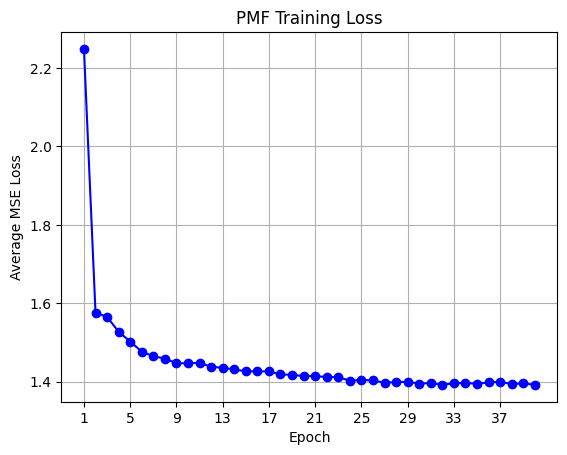

In [16]:
# Plot epoch vs. Avg MSE loss
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', linestyle='-', color='b')
plt.title('PMF Training Loss')
plt.xticks(range(1, epochs + 1, 4))
plt.xlabel('Epoch')
plt.ylabel('Average MSE Loss')
plt.grid(True)

plt.tight_layout()
plt.savefig('../figures/PMF_training_loss.png', bbox_inches='tight', dpi=300)
plt.show()

In [17]:
# Extract embeddings
user_embeddings, movie_embeddings = model.get_embeddings()

# Save embeddings for later use
np.save('../data/user_embeddings.npy', user_embeddings)
np.save('../data/movie_embeddings.npy', movie_embeddings)

print(f"User embeddings: {user_embeddings.shape}")
print(f"Movie embeddings: {movie_embeddings.shape}")

User embeddings: (6040, 100)
Movie embeddings: (3706, 100)
